# Steel Defect Detection in Sugarcane Mill Machinery

## Modules

In [1]:
import os
import csv
import random
import numpy as np
import pandas as pd
import cv2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim

In [4]:
import segmentation_models_pytorch as smp

e:\Studies\MIT\8\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configs

### Random Seed

In [5]:
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

### CUDA Check

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA Available:", torch.cuda.is_available())
print("Device:", device)

CUDA Available: True
Device: cuda


### Dataset Directory

In [7]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..\\\\.."))
DATA_DIR = os.path.join(ROOT_DIR, "Datasets", "steel-defect-detection")
TRAIN_CSV_PATH = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(DATA_DIR, "test_images")

print(f"""
CSV Path: {(TRAIN_CSV_PATH, os.path.exists(TRAIN_CSV_PATH))}
Train Images Directory: {(TRAIN_IMAGES_DIR, os.path.exists(TRAIN_IMAGES_DIR))}
Test Images Directory: {(TEST_IMAGES_DIR, os.path.exists(TEST_IMAGES_DIR))}
"""
)



CSV Path: ('e:\\Studies\\MIT\\8\\Project\\Datasets\\steel-defect-detection\\train.csv', True)
Train Images Directory: ('e:\\Studies\\MIT\\8\\Project\\Datasets\\steel-defect-detection\\train_images', True)
Test Images Directory: ('e:\\Studies\\MIT\\8\\Project\\Datasets\\steel-defect-detection\\test_images', True)



### Image Configs

In [8]:
NUM_CLASSES = 4
IMG_HEIGHT = 256
IMG_WIDTH = 1600
BATCH_SIZE = 8
IMAGE_SIZE = (IMG_HEIGHT, IMG_HEIGHT)
PATCH_SIZE = 256

### Training Configs

In [9]:
THRESHOLD = 0.5
EPOCHS = 10
MAX_EPOCHS = 50
PATIENCE = 50
MODEL_NAME = "mit_b4"

### Saving the Model

In [10]:
BEST_MODEL_DIRECTORY = os.path.join(ROOT_DIR, "Models", "Steel", MODEL_NAME)
print(f"Best Model Directory: {BEST_MODEL_DIRECTORY}")
# Create directory if it doesn't exist
os.makedirs(BEST_MODEL_DIRECTORY, exist_ok=True)
print("Directory created (if it didn't exist):", BEST_MODEL_DIRECTORY)

Best Model Directory: e:\Studies\MIT\8\Project\Models\Steel\mit_b4
Directory created (if it didn't exist): e:\Studies\MIT\8\Project\Models\Steel\mit_b4


In [11]:
## Fetch latest name of best model from BEST_MODEL_DIRECTORY and increment the number in the name by 1, to create new BEST_MODEL_PATH
existing_models = [f for f in os.listdir(BEST_MODEL_DIRECTORY) if f.endswith(".pth")]
if existing_models:
    existing_models.sort()
    latest_model = existing_models[-1]
    latest_number = int(latest_model.split(".")[0])
    new_number = latest_number + 1
else:
    new_number = 1

In [12]:
BEST_MODEL_PATH = str(new_number) + ".pth"
BEST_MODEL_PATH

'7.pth'

In [13]:
BEST_MODEL_PATH = os.path.join(BEST_MODEL_DIRECTORY, BEST_MODEL_PATH)
BEST_MODEL_PATH = os.path.abspath(BEST_MODEL_PATH)
print("Best model path:", BEST_MODEL_PATH)

Best model path: e:\Studies\MIT\8\Project\Models\Steel\mit_b4\7.pth


### Results Directory

In [14]:
RESULTS_DIR = os.path.join(ROOT_DIR, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_FILE = os.path.join(RESULTS_DIR, "model_results_steel.csv")
print("Results file path:", RESULTS_FILE)

Results file path: e:\Studies\MIT\8\Project\Results\model_results_steel.csv


## Data Preprocessing

In [15]:
df = pd.read_csv(TRAIN_CSV_PATH)

In [16]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


In [17]:
df.shape

(7095, 3)

In [18]:
df.dtypes

ImageId            str
ClassId          int64
EncodedPixels      str
dtype: object

In [19]:
no_of_images = df["ImageId"].nunique()
print(f"Number of unique images: {no_of_images}")


Number of unique images: 6666


### Image and Defect Class Relationship

Expected to have 4 entries for each image corresponding to each class of defect (1, 2, 3, 4), regardless of whether or not the particular image has a defect of said class ID.

In [20]:
df['ImageId'].value_counts().head(10)

ImageId
db4867ee8.jpg    3
ef24da2ba.jpg    3
0025bde0c.jpg    2
002fc4e19.jpg    2
008ef3d74.jpg    2
00ac8372f.jpg    2
00c88fed0.jpg    2
012f26693.jpg    2
01cfacf80.jpg    2
0391d44d6.jpg    2
Name: count, dtype: int64

In [21]:
print(f"Count of Images with not all categories of class defect data available: {int((df['ImageId'].value_counts() != 4).sum())}/{no_of_images}")

Count of Images with not all categories of class defect data available: 6666/6666


### Creating Full Dataset

In [22]:
all_images = df['ImageId'].unique()
all_classes = [1, 2, 3, 4]

In [23]:
full_index = pd.MultiIndex.from_product(
    [all_images, all_classes],
    names=['ImageId', 'ClassId']
)

In [24]:
df_full = (
    df.set_index(['ImageId', 'ClassId'])
      .reindex(full_index)
      .reset_index()
)

In [25]:
df_full.shape

(26664, 3)

In [26]:
df_full.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0002cc93b.jpg,2,NaN
2,0002cc93b.jpg,3,NaN
3,0002cc93b.jpg,4,NaN
4,0007a71bf.jpg,1,NaN
5,0007a71bf.jpg,2,NaN
6,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
7,0007a71bf.jpg,4,NaN
8,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
9,000a4bcdd.jpg,2,NaN


In [27]:
df_full['ImageId'].value_counts().head()

ImageId
0002cc93b.jpg    4
0007a71bf.jpg    4
000a4bcdd.jpg    4
000f6bf48.jpg    4
0014fce06.jpg    4
Name: count, dtype: int64

In [28]:
print(f"Count of images with not all categories of class defect data available: {int((df_full['ImageId'].value_counts() != 4).sum())}/{no_of_images}")

Count of images with not all categories of class defect data available: 0/6666


In [29]:
print(f"Defect presence in percentage: {df_full['EncodedPixels'].isna().mean() * 100:.2f}%")

Defect presence in percentage: 73.39%


In [30]:
OUTPUT_CSV_PATH = os.path.join(DATA_DIR, "train_full.csv")
df_full.to_csv(OUTPUT_CSV_PATH, index=False)

### Essentials

In [31]:
image_level_defects = (
    df_full.groupby('ImageId')['EncodedPixels']
           .apply(lambda x: x.notna().any())
)
image_level_defects.value_counts()

EncodedPixels
True    6666
Name: count, dtype: int64

In [32]:
df_full['has_defect'] = ~df_full['EncodedPixels'].isna()

class_distribution = (
    df_full.groupby('ClassId')['has_defect']
      .mean()
      .rename('defect_ratio')
)

print("Per-Class Defect Frequency", class_distribution, sep="\n")

Per-Class Defect Frequency
ClassId
1    0.134563
2    0.037054
3    0.772577
4    0.120162
Name: defect_ratio, dtype: float64


In [33]:
print(f"No. of unique images:", df_full['ImageId'].nunique())
print(f"No. of images with no defects:", image_level_defects.value_counts().sum())

No. of unique images: 6666
No. of images with no defects: 6666


In [34]:
train_images_dir = os.path.join(DATA_DIR, "train_images")

missing_files = [
    img for img in df['ImageId'].unique()
    if not os.path.exists(os.path.join(train_images_dir, img))
]

print("Missing image files count:", len(missing_files))

Missing image files count: 0


### Run Length Decoder

Run Length Encoding (RLE) is a simple lossless compression technique that represents consecutive occurrences of the same value as a single value–count pair, for example encoding a long sequence of identical pixels as “(value, run length)” instead of storing each pixel individually. 

It is used here because the mage-processing pipeline contains large contiguous regions with uniform or near-uniform values, such as background areas, binary masks, segmentation maps, or thresholded images, and RLE exploits this spatial redundancy to reduce storage, transmission bandwidth, and memory footprint without losing any information.

The encoded data has to be decoded appropriately into a binary mask via the run length decoder below after the output from the vision module is obtained. For this purpose, run length decoding is performed.

In [35]:
def rle_decode(rle_string, height=IMG_HEIGHT, width=IMG_WIDTH):
    mask = np.zeros(height * width, dtype=np.uint8)

    if pd.isna(rle_string):
        return mask.reshape((width, height)).T

    rle = list(map(int, rle_string.split()))
    starts = rle[0::2]
    lengths = rle[1::2]

    for start, length in zip(starts, lengths):
        start -= 1
        mask[start:start + length] = 1

    return mask.reshape((width, height)).T


### Channel Mask Construction

Builds a 4-channel mask (4, H, W) for a single image, each channel for a defect class.

In [36]:
def build_mask_for_image(image_id, df_full):

    mask = np.zeros((NUM_CLASSES, IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)

    image_rows = df_full[df_full['ImageId'] == image_id]

    for _, row in image_rows.iterrows():
        class_idx = int(row['ClassId']) - 1
        mask[class_idx] = rle_decode(
            row['EncodedPixels'],
            IMG_HEIGHT,
            IMG_WIDTH
        )

    return mask


### Sanity Check

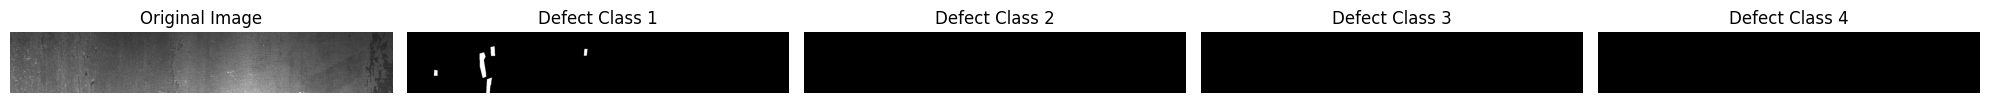

In [37]:
sample_image_id = df_full['ImageId'].iloc[0]

image_path = os.path.join(TRAIN_IMAGES_DIR, sample_image_id)
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = build_mask_for_image(sample_image_id, df_full)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

for i in range(4):
    axes[i + 1].imshow(mask[i], cmap="gray")
    axes[i + 1].set_title(f"Defect Class {i + 1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()


## Knowledge Graph

In [38]:
G = nx.DiGraph()

### Nodes

#### Input Nodes

In [39]:
layer_input = [
    "Defect_Class_1_Detected",
    "Defect_Class_2_Detected",
    "Defect_Class_3_Detected",
    "Defect_Class_4_Detected"
]

#### Attribute Nodes

In [40]:
layer_attributes = [
    "Defect_Area",
    "Defect_Length",
    "Defect_Density",
    "Defect_Distribution"
]

#### Defect Interpretation Nodes

In [41]:
layer_interpretation = [
    "Isolated_Minor_Defect",
    "Localized_Severe_Defect",
    "Widespread_Defect_Pattern",
    "Critical_Structural_Defect"
]

#### Quality Assessment Nodes

In [42]:
layer_quality = [
    "Acceptable_Quality",
    "Marginal_Quality",
    "Unacceptable_Quality"
]

#### Decision and Action Nodes

In [43]:
layer_decision = [
    "Accept_Strip",
    "Downgrade_Strip",
    "Reject_Strip",
    "Manual_Inspection_Required"
]

### Edges

#### Input to Attribute Edges

In [44]:
edges_evidence_to_attr = [
    ("Defect_Class_1_Detected", "Defect_Area", "if present"),
    ("Defect_Class_2_Detected", "Defect_Area", "if present"),
    ("Defect_Class_3_Detected", "Defect_Density", "if clustered"),
    ("Defect_Class_4_Detected", "Defect_Length", "if elongated"),

    ("Defect_Class_1_Detected", "Defect_Distribution", ""),
    ("Defect_Class_2_Detected", "Defect_Distribution", ""),
    ("Defect_Class_3_Detected", "Defect_Distribution", ""),
    ("Defect_Class_4_Detected", "Defect_Distribution", "")
]

#### Attribute to Interpretation Edges

In [45]:
edges_attr_to_interp = [
    ("Defect_Area", "Isolated_Minor_Defect", "area < T1"),
    ("Defect_Area", "Localized_Severe_Defect", "area ≥ T2"),
    ("Defect_Length", "Critical_Structural_Defect", "length ≥ T3"),
    ("Defect_Density", "Widespread_Defect_Pattern", "density ≥ T4"),
    ("Defect_Distribution", "Widespread_Defect_Pattern", "distributed")
]

#### Interpretation to Quality Edges

In [46]:
edges_interp_to_quality = [
    ("Isolated_Minor_Defect", "Acceptable_Quality", ""),
    ("Localized_Severe_Defect", "Marginal_Quality", ""),
    ("Widespread_Defect_Pattern", "Unacceptable_Quality", ""),
    ("Critical_Structural_Defect", "Unacceptable_Quality", "")
]

#### Quality to Decision Edges

In [47]:
edges_quality_to_decision = [
    ("Acceptable_Quality", "Accept_Strip", ""),
    ("Marginal_Quality", "Downgrade_Strip", ""),
    ("Unacceptable_Quality", "Reject_Strip", "")
]

### Adding Nodes and Edges to Graph

In [48]:
for node in layer_input:
    G.add_node(node, layer=1)
    
for node in layer_attributes:
    G.add_node(node, layer=2)
    
for node in layer_interpretation:
    G.add_node(node, layer=3)

for node in layer_quality:
    G.add_node(node, layer=4)

for node in layer_decision:
    G.add_node(node, layer=5)

for src, dst, cond in edges_evidence_to_attr:
    G.add_edge(src, dst, condition=cond)

for src, dst, cond in edges_attr_to_interp:
    G.add_edge(src, dst, condition=cond)

for src, dst, cond in edges_interp_to_quality:
    G.add_edge(src, dst, condition=cond)

for src, dst, cond in edges_quality_to_decision:
    G.add_edge(src, dst, condition=cond)

G.add_edge(
    "Critical_Structural_Defect",
    "Manual_Inspection_Required",
    condition="safety-critical"
)

### Visualization

In [49]:
def layered_layout(G):
    pos = {}
    layer_nodes = {}

    for node, data in G.nodes(data=True):
        layer = data["layer"]
        layer_nodes.setdefault(layer, []).append(node)

    for layer, nodes in layer_nodes.items():
        for i, node in enumerate(nodes):
            pos[node] = (i, -layer)

    return pos

In [50]:
layer_colors = {
    1: "#AED6F1",  # Input Evidence (light blue)
    2: "#A9DFBF",  # Spatial / Severity Attributes (light green)
    3: "#F9E79F",  # Interpretation (light yellow)
    4: "#F5CBA7",  # Quality Assessment (light orange)
    5: "#F1948A"   # Decision & Action (light red)
}

In [51]:
nodes_by_layer = {}

for node, data in G.nodes(data=True):
    layer = data["layer"]
    nodes_by_layer.setdefault(layer, []).append(node)

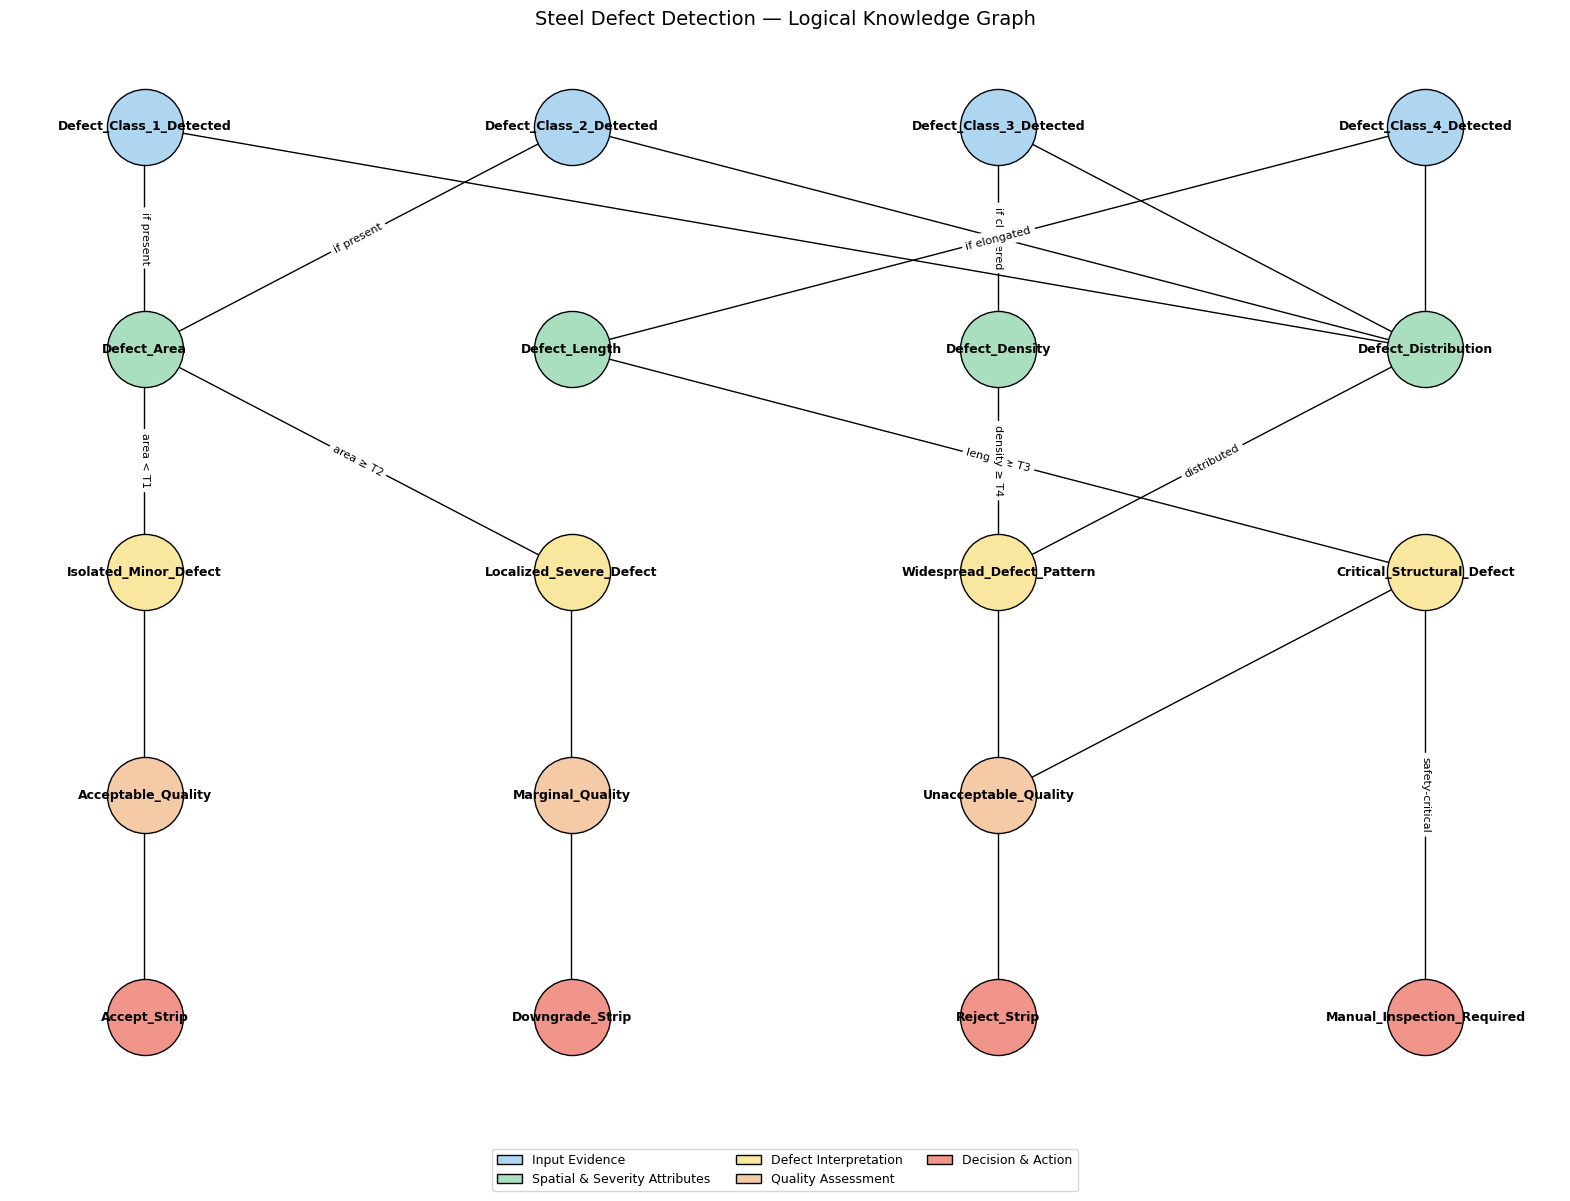

In [52]:
pos = layered_layout(G)

plt.figure(figsize=(20, 14))

for layer, nodes in nodes_by_layer.items():
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes,
        node_color=layer_colors[layer],
        node_size=3000,
        edgecolors="black",
        linewidths=1.0,
        label=f"Layer {layer}"
    )

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=15
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

edge_labels = {
    (u, v): d["condition"]
    for u, v, d in G.edges(data=True)
    if d["condition"]
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

legend_patches = [
    Patch(facecolor=layer_colors[1], edgecolor="black", label="Input Evidence"),
    Patch(facecolor=layer_colors[2], edgecolor="black", label="Spatial & Severity Attributes"),
    Patch(facecolor=layer_colors[3], edgecolor="black", label="Defect Interpretation"),
    Patch(facecolor=layer_colors[4], edgecolor="black", label="Quality Assessment"),
    Patch(facecolor=layer_colors[5], edgecolor="black", label="Decision & Action"),
]

plt.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08), 
    ncol=3,
    frameon=True,
    fontsize=9
)

plt.title("Steel Defect Detection — Logical Knowledge Graph", fontsize=14)
plt.axis("off")

## Save the graph visualization to Media (as Steel_Defect_Detection_KG.png)
output_path = os.path.join(ROOT_DIR, "Media", "Steel_Defect_Detection_KG.png")
plt.savefig(output_path)

plt.show()


## Dataset

### Dataset Class

In [53]:
class SteelSegmentationDataset(Dataset):
    def __init__(self, df_full, image_dir, patch_size=256):
        self.df_full = df_full
        self.image_dir = image_dir
        self.image_ids = df_full['ImageId'].unique()
        self.patch_size = patch_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load image (FULL SIZE)

        img_path = os.path.join(self.image_dir, image_id)
        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.float32) / 255.0

        # Build FULL mask (256 × 1600)
        mask = np.zeros((4, 256, 1600), dtype=np.uint8)

        rows = self.df_full[self.df_full['ImageId'] == image_id]

        for _, row in rows.iterrows():
            class_idx = int(row['ClassId']) - 1
            decoded = rle_decode(row['EncodedPixels'])
            mask[class_idx] = decoded

        # PATCH SAMPLING
        max_x = 1600 - self.patch_size

        if np.random.rand() < 0.7:
            # Try to find defect patch
            for _ in range(5):
                x_start = np.random.randint(0, max_x + 1)
                mask_patch = mask[:, :, x_start:x_start + self.patch_size]

                if mask_patch.sum() > 0:
                    break
        else:
            # Random patch
            x_start = np.random.randint(0, max_x + 1)
            mask_patch = mask[:, :, x_start:x_start + self.patch_size]

        # Final patch extraction
        image_patch = image[:, x_start:x_start + self.patch_size]

        # -------------------------
        # Convert to tensor
        # -------------------------
        image_patch = torch.from_numpy(image_patch).permute(2, 0, 1)
        mask_patch = torch.from_numpy(mask_patch).float()

        return image_patch, mask_patch

### Train Dataset

In [54]:
full_train_dataset = SteelSegmentationDataset(
    df_full=df_full,
    image_dir=TRAIN_IMAGES_DIR,
    patch_size=PATCH_SIZE
)

print("No. of train images:", len(full_train_dataset))

No. of train images: 6666


### Train-Validation Split

In [55]:
train_size = int(0.7 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(random_seed)
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 4666
Validation samples: 2000


### Dataloaders

In [56]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### After Batch Division

In [57]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 4, 256, 256])


## Model

### mit_b4

In [58]:
model = smp.Unet(
    encoder_name=MODEL_NAME,
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)

In [59]:
model

Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=64

### Move to GPU

In [60]:
model = model.to(device)
print("Model moved to:", device)

Model moved to: cuda


### Trainable Parameters

In [61]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 64,123,844
Trainable parameters: 64,123,844


## Training

### Loss Function

Using only Binary Cross Entropy often leads to poor segmentation of thin defects.

Therefore we combine: BCE + Dice

BCE: Handles pixel-wise classification.

Dice Loss: Measures overlap between predicted and true masks.

#### Dice Loss

In [62]:
# class DiceLoss(nn.Module):
    
#     def __init__(self, smooth=1):
#         super().__init__()
#         self.smooth = smooth

#     def forward(self, preds, targets):

#         preds = torch.sigmoid(preds)

#         preds = preds.view(-1)
#         targets = targets.view(-1)

#         intersection = (preds * targets).sum()

#         dice = (2. * intersection + self.smooth) / \
#                (preds.sum() + targets.sum() + self.smooth)

#         return 1 - dice

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        # flatten per batch, per class
        preds = preds.reshape(preds.size(0), preds.size(1), -1)
        targets = targets.reshape(targets.size(0), targets.size(1), -1)

        intersection = (preds * targets).sum(dim=2)
        union = preds.sum(dim=2) + targets.sum(dim=2)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        # average over classes and batch
        return 1 - dice.mean()

#### BCE-Dice

In [63]:
# class BCEDiceLoss(nn.Module):

#     def __init__(self):
#         super().__init__()
#         self.bce = nn.BCEWithLogitsLoss()
#         self.dice = DiceLoss()

#     def forward(self, preds, targets):

#         bce_loss = self.bce(preds, targets)
#         dice_loss = self.dice(preds, targets)

#         return bce_loss + dice_loss

class BCEDiceLoss(nn.Module):

    def __init__(self, pos_weight=None):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.dice = DiceLoss()

    def forward(self, preds, targets):

        bce_loss = self.bce(preds, targets)
        dice_loss = self.dice(preds, targets)

        return bce_loss + dice_loss

#### Dice Score

In [64]:
# def dice_score(preds, targets, threshold=0.5):

#     preds = torch.sigmoid(preds)
#     preds = (preds > threshold).float()

#     intersection = (preds * targets).sum()
#     union = preds.sum() + targets.sum()

#     return (2 * intersection) / (union + 1e-8)

def dice_score(preds, targets, threshold=THRESHOLD):

    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.reshape(preds.size(0), preds.size(1), -1)
    targets = targets.reshape(targets.size(0), targets.size(1), -1)

    intersection = (preds * targets).sum(dim=2)
    union = preds.sum(dim=2) + targets.sum(dim=2)

    dice = (2 * intersection) / (union + 1e-8)

    dice[union == 0] = 1.0

    return dice.mean()


def dice_per_class(preds, targets, threshold=THRESHOLD):

    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    # reshape: (B, C, H, W) → (B, C, N)
    preds = preds.reshape(preds.size(0), preds.size(1), -1)
    targets = targets.reshape(targets.size(0), targets.size(1), -1)

    intersection = (preds * targets).sum(dim=2)
    union = preds.sum(dim=2) + targets.sum(dim=2)

    dice = (2 * intersection) / (union + 1e-8)

    dice[union == 0] = 1.0

    # shape: (B, C)
    return dice

#### IoU Score

In [65]:
def iou_score(preds, targets, threshold=0.5):

    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection

    return intersection / (union + 1e-8)

In [66]:
# criterion = BCEDiceLoss()

pos_weight = torch.tensor([3.0, 3.0, 2.0, 1.0]).to(device).view(1, 4, 1, 1)

criterion = BCEDiceLoss(pos_weight=pos_weight)

### Optimizer

In [67]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

### Train Function

In [68]:
def train_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

### Validate Function

In [69]:
# def validate_epoch(model, loader, criterion):

#     model.eval()

#     running_loss = 0
#     dice_total = 0
#     iou_total = 0

#     with torch.no_grad():

#         for images, masks in loader:

#             images = images.to(device)
#             masks = masks.to(device)

#             outputs = model(images)

#             loss = criterion(outputs, masks)

#             running_loss += loss.item()

#             dice_total += dice_score(outputs, masks)
#             iou_total += iou_score(outputs, masks)

#     avg_loss = running_loss / len(loader)
#     avg_dice = dice_total / len(loader)
#     avg_iou = iou_total / len(loader)

#     return avg_loss, avg_dice, avg_iou

def validate_epoch(model, loader, criterion):

    model.eval()

    running_loss = 0
    dice_total = 0
    iou_total = 0

    # NEW: per-class accumulator
    per_class_dice_total = torch.zeros(4, device=device)

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)
            running_loss += loss.item()

            # overall Dice
            batch_dice = dice_score(outputs, masks)
            dice_total += batch_dice

            # IoU
            iou_total += iou_score(outputs, masks)

            # NEW: per-class Dice
            dice_pc = dice_per_class(outputs, masks)   # (B, C)
            per_class_dice_total += dice_pc.mean(dim=0)  # (C,)

    avg_loss = running_loss / len(loader)
    avg_dice = dice_total / len(loader)
    avg_iou = iou_total / len(loader)

    avg_per_class_dice = per_class_dice_total / len(loader)

    return avg_loss, avg_dice, avg_iou, avg_per_class_dice

### Training Loop

In [70]:
best_val_dice = 0.0
best_val_dice_pc = torch.zeros(4)

epochs_without_improvement = 0

train_losses = []
val_losses = []
val_dices = []
val_dices_per_class = []

# print(
#     f"{'Epoch':<8}"
#     f"{'Train Loss':<15}"
#     f"{'Val Loss':<15}"
#     f"{'Dice':<12}"
#     f"{'IoU':<12}"
#     f"{'Status':<20}"
# )

# print("-" * 80)

print(
    f"{'Epoch':<6}"
    f"{'Train Loss':<14}"
    f"{'Val Loss':<14}"
    f"{'Dice':<10}"
    f"{'IoU':<10}"
    f"{'C1':<8}{'C2':<8}{'C3':<8}{'C4':<8}"
    f"{'Status':<20}"
)

print("-" * 110)

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    # val_loss, val_dice, val_iou = validate_epoch(
    #     model,
    #     val_loader,
    #     criterion
    # )

    val_loss, val_dice, val_iou, val_dice_pc = validate_epoch(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # val_dices.append(val_dice)
    val_dices.append(val_dice.item())
    val_dices_per_class.append(val_dice_pc.cpu().numpy())

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        epochs_without_improvement = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        best_val_dice_pc = val_dice_pc.clone().detach()

        status = "New Best Model"

    else:

        epochs_without_improvement += 1
        status = f"No Improvement ({epochs_without_improvement}/{PATIENCE})"

    # print(
    #     f"{epoch:<8}"
    #     f"{train_loss:<15.4f}"
    #     f"{val_loss:<15.4f}"
    #     f"{val_dice:<12.4f}"
    #     f"{val_iou:<12.4f}"
    #     f"{status:<20}"
    # )

    c1, c2, c3, c4 = val_dice_pc.tolist()

    print(
        f"{epoch:<6}"
        f"{train_loss:<14.4f}"
        f"{val_loss:<14.4f}"
        f"{val_dice:<10.4f}"
        f"{val_iou:<10.4f}"
        f"{c1:<8.4f}{c2:<8.4f}{c3:<8.4f}{c4:<8.4f}"
        f"{status:<20}"
    )

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Best validation Dice: {best_val_dice:.4f}")
        break

Epoch Train Loss    Val Loss      Dice      IoU       C1      C2      C3      C4      Status              
--------------------------------------------------------------------------------------------------------------
1     1.2029        1.0243        0.7198    0.4703    0.8715  0.6770  0.5031  0.8276  New Best Model      
2     0.9989        0.9729        0.7823    0.5166    0.8835  0.9825  0.5651  0.6980  New Best Model      
3     0.9672        0.9540        0.8393    0.5434    0.8861  0.9740  0.6041  0.8931  New Best Model      
4     0.9581        0.9529        0.8224    0.5254    0.8591  0.9855  0.5989  0.8461  No Improvement (1/50)
5     0.9463        0.9405        0.8292    0.5646    0.8015  0.9779  0.5991  0.9385  No Improvement (2/50)
6     0.9370        0.9347        0.8259    0.5506    0.8071  0.9455  0.6180  0.9330  No Improvement (3/50)
7     0.9378        0.9326        0.8486    0.5727    0.8152  0.9763  0.6512  0.9517  New Best Model      
8     0.9261        0.9273    

## Results

### Load Best Model

In [71]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

print("Best Validation Dice =", best_val_dice)

Best Validation Dice = tensor(0.8884, device='cuda:0')


### Add Results to CSV

In [72]:
# epochs_trained = len(train_losses)

# row = [
#     MODEL_NAME,
#     round(best_val_dice.item(), 5),
#     epochs_trained
# ]

# file_exists = os.path.isfile(RESULTS_FILE)

# with open(RESULTS_FILE, mode="a", newline="") as f:
#     writer = csv.writer(f)

#     # Write header only once
#     if not file_exists:
#         writer.writerow([
#             "model_name",
#             "best_val_dice",
#             "epochs_trained"
#         ])

#     writer.writerow(row)

# print(f"Results logged successfully to {RESULTS_FILE}.")
# print("Logged row:", row)

epochs_trained = len(train_losses)

# Convert per-class dice to list
c1, c2, c3, c4 = best_val_dice_pc.cpu().numpy()

row = [
    MODEL_NAME,
    round(best_val_dice.item(), 5),
    round(float(c1), 5),
    round(float(c2), 5),
    round(float(c3), 5),
    round(float(c4), 5),
    epochs_trained
]

file_exists = os.path.isfile(RESULTS_FILE)

with open(RESULTS_FILE, mode="a", newline="") as f:
    writer = csv.writer(f)

    # Write header only once
    if not file_exists:
        writer.writerow([
            "model_name",
            "best_val_dice",
            "dice_c1",
            "dice_c2",
            "dice_c3",
            "dice_c4",
            "epochs_trained"
        ])

    writer.writerow(row)

print(f"Results logged successfully to {RESULTS_FILE}.")
print("Logged row:", row)

Results logged successfully to e:\Studies\MIT\8\Project\Results\model_results_steel.csv.
Logged row: ['mit_b4', 0.88838, 0.92365, 0.98581, 0.71095, 0.93312, 50]


### Loss and Dice Score Curves

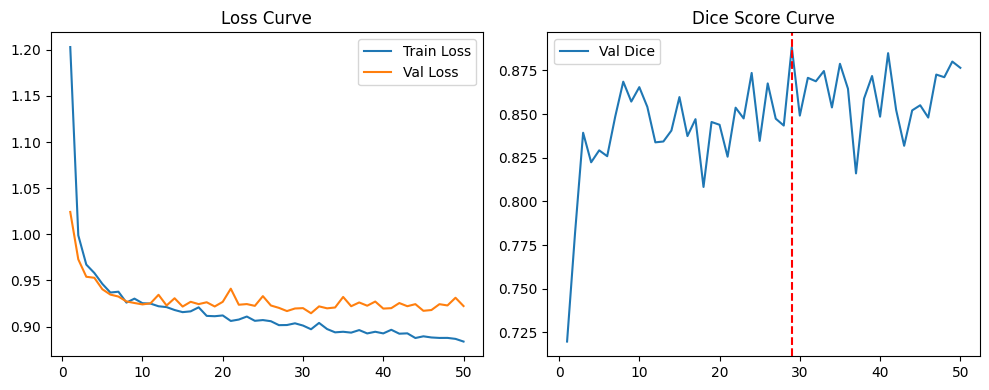

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10,4))

# Loss curves
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

# Dice curves
plt.subplot(1,2,2)
plt.plot(epochs_range, val_dices, label="Val Dice")
plt.legend()
plt.title("Dice Score Curve")

best_epoch = val_dices.index(max(val_dices)) + 1
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')

plt.tight_layout()
plt.show()